# A/B Test Analysis: SMS Re-engagement Campaign

Author: Tobi Bolu | [LinkedIn](https://www.linkedin.com/in/tobibolu/) | [GitHub](https://github.com/tobibolu)

I'm designing and simulating an A/B test for an SMS re-engagement campaign targeting at-risk customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, norm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})
np.random.seed(42)


/Users/tobibolu/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Step 1: Load Cleaned Data

I'm loading the cleaned dataset from the previous EDA step.

In [2]:
# Loading the cleaned dataset from the EDA step
df = pd.read_csv('./cleaned_data.csv')
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

Loaded dataset: 974 rows, 21 columns

Columns: ['Customer ID', 'Full Name', 'Date of Purchase', 'Age', 'State', 'MTN Device', 'Gender', 'Satisfaction Rate', 'Customer Review', 'Customer Tenure in months', 'Subscription Plan', 'Unit Price', 'Number of Times Purchased', 'Total Revenue', 'Data Usage', 'Customer Churn Status', 'Reasons for Churn', 'Subscription Plan_encoded', 'tenure_x_Data Usage', 'charge_per_usage', 'Age_binned']

First few rows:
  Customer ID     Full Name Date of Purchase  Age        State  \
0    CUST0001   Ngozi Berry           Jan-25   27        Kwara   
1    CUST0002  Zainab Baker           Mar-25   16  Abuja (FCT)   
2    CUST0003   Saidu Evans           Mar-25   21       Sokoto   
3    CUST0003   Saidu Evans           Mar-25   21       Sokoto   
4    CUST0003   Saidu Evans           Mar-25   21       Sokoto   

            MTN Device  Gender  Satisfaction Rate Customer Review  \
0            4G Router    Male                  2            Fair   
1      Mobile SI

## Step 2: Identify At-Risk Customers

I'm segmenting customers as 'at-risk' based on behavioral patterns.

In [3]:
# Setting up column mapping (same adaptive approach as notebook 01)
columns_lower = {col: col_orig for col_orig in df.columns for col in [col_orig.lower()]}
all_cols_lower = [c.lower() for c in df.columns]

def find_column(patterns):
    if isinstance(patterns, str):
        patterns = [patterns]
    for pattern in patterns:
        for col in all_cols_lower:
            if pattern in col:
                return [c for c in df.columns if c.lower() == col][0]
    return None

churn_col = find_column(['churn', 'churned', 'attrition'])
tenure_col = find_column(['tenure', 'months'])
usage_cols = [c for c in df.columns if any(p in c.lower() for p in ['usage', 'minutes', 'calls', 'data'])]
complaint_col = find_column(['complaint', 'support'])

# Creating at-risk customer flag
df['at_risk'] = 0

# Flagging low-tenure customers (< 10th percentile)
if tenure_col and tenure_col in df.columns:
    low_tenure_threshold = df[tenure_col].quantile(0.1)
    df.loc[df[tenure_col] < low_tenure_threshold, 'at_risk'] = 1
    print(f"Low tenure threshold: {low_tenure_threshold:.1f} months")

# Flagging low-usage customers (if we can detect it from data pattern)
if usage_cols:
    first_usage = usage_cols[0]
    if first_usage in df.columns:
        low_usage_threshold = df[first_usage].quantile(0.25)
        df.loc[df[first_usage] < low_usage_threshold, 'at_risk'] = 1
        print(f"Low usage threshold: {low_usage_threshold:.1f}")

# Flagging customers with complaints (if available)
if complaint_col and complaint_col in df.columns:
    df.loc[df[complaint_col] > 0, 'at_risk'] = 1
    print(f"Customers with complaints marked as at-risk")

at_risk_count = df['at_risk'].sum()
at_risk_pct = at_risk_count / len(df) * 100
print(f"\nAt-risk customers: {at_risk_count} ({at_risk_pct:.1f}%)")
print(f"Available for targeting: {at_risk_count}")

Low tenure threshold: 7.3 months
Low usage threshold: 47.6

At-risk customers: 316 (32.4%)
Available for targeting: 316


## Step 3: A/B Test Design

I'm designing a hypothesis test for the SMS re-engagement campaign.

In [4]:
# Defining the campaign hypothesis
print("HYPOTHESIS FRAMEWORK:")
print("=" * 60)
print("Campaign: SMS Re-engagement Program")
print("Target: At-risk customers (low tenure, low usage, or complaints)")
print("")
print("H0 (Null): SMS campaign has NO effect on retention")
print("           P(retain | control) = P(retain | treatment)")
print("")
print("H1 (Alt):  SMS campaign IMPROVES retention")
print("           P(retain | treatment) > P(retain | control)")
print("")
print("Expected Effect: 6-8% absolute lift in retention rate")
print("Significance Level: α = 0.05 (95% confidence)")
print("Power: 1 - β = 0.80 (80% power)")
print("=" * 60)

# Calculating baseline churn rate
if churn_col and churn_col in df.columns:
    base_churn_rate = df[churn_col].map({'Yes': 1, 'No': 0}).mean()
    base_retention_rate = 1 - base_churn_rate
    print(f"\nBase churn rate (overall): {base_churn_rate*100:.2f}%")
    print(f"Base retention rate: {base_retention_rate*100:.2f}%")

    # At-risk segment likely has higher churn
    at_risk_churn = df[df['at_risk'] == 1][churn_col].map({'Yes': 1, 'No': 0}).mean()
    print(f"At-risk segment churn rate: {at_risk_churn*100:.2f}%")
    print(f"At-risk retention rate: {(1-at_risk_churn)*100:.2f}%")

HYPOTHESIS FRAMEWORK:
Campaign: SMS Re-engagement Program
Target: At-risk customers (low tenure, low usage, or complaints)

H0 (Null): SMS campaign has NO effect on retention
           P(retain | control) = P(retain | treatment)

H1 (Alt):  SMS campaign IMPROVES retention
           P(retain | treatment) > P(retain | control)

Expected Effect: 6-8% absolute lift in retention rate
Significance Level: α = 0.05 (95% confidence)
Power: 1 - β = 0.80 (80% power)

Base churn rate (overall): 29.16%
Base retention rate: 70.84%
At-risk segment churn rate: 25.32%
At-risk retention rate: 74.68%


## Step 4: Sample Size Calculation

I'm calculating the required sample size for adequate statistical power.

In [5]:
# Calculating required sample size for adequate power
# Effect size: 6% lift from baseline retention
if churn_col and churn_col in df.columns:
    at_risk_churn = df[df['at_risk'] == 1][churn_col].map({'Yes': 1, 'No': 0}).mean()
    at_risk_retention = 1 - at_risk_churn

    # Control: baseline retention
    p1 = at_risk_retention
    # Treatment: 6% absolute lift
    p2 = at_risk_retention + 0.06

    # Computing effect size (Cohen's h)
    h = 2 * (np.arcsin(np.sqrt(p2)) - np.arcsin(np.sqrt(p1)))

    # Applying sample size formula for 80% power for 80% power, 0.05 significance (two-tailed)
    # n = 2 * ((z_alpha + z_beta) / h)^2
    z_alpha = norm.ppf(1 - 0.05/2)  # two-tailed
    z_beta = norm.ppf(0.80)

    n_per_group = (2 * (z_alpha + z_beta)**2) / (h**2)

    print(f"SAMPLE SIZE CALCULATION:")
    print(f"Control retention rate: {p1*100:.2f}%")
    print(f"Treatment retention rate (6% lift): {p2*100:.2f}%")
    print(f"Effect size (Cohen's h): {h:.3f}")
    print(f"Required per group: {int(n_per_group)} customers")
    print(f"Total sample size: {int(2*n_per_group)} customers")
    print(f"\nAvailable at-risk sample: {at_risk_count}")

    # Using available at-risk customers
    sample_size = min(int(n_per_group * 2), at_risk_count)
    sample_per_group = sample_size // 2
    print(f"Using: {sample_size} customers ({sample_per_group} per group)")
else:
    sample_per_group = min(200, at_risk_count // 2)
    sample_size = sample_per_group * 2
    print(f"Sample size: {sample_size} ({sample_per_group} per group)")

SAMPLE SIZE CALCULATION:
Control retention rate: 74.68%
Treatment retention rate (6% lift): 80.68%
Effect size (Cohen's h): 0.144
Required per group: 752 customers
Total sample size: 1505 customers

Available at-risk sample: 316
Using: 316 customers (158 per group)


## Step 5: Simulate A/B Test Results

I'm simulating the campaign outcomes with realistic conversion rates.

In [6]:
# Setting up the A/B test with random group assignment
at_risk_df = df[df['at_risk'] == 1].copy()

# Randomly assign to control/treatment
test_sample = at_risk_df.sample(n=min(sample_size, len(at_risk_df)), random_state=42).copy()
test_sample['group'] = np.random.choice(['control', 'treatment'], size=len(test_sample), p=[0.5, 0.5])

# Getting baseline retention rate for the at-risk segment
if churn_col and churn_col in df.columns:
    at_risk_churn = df[df['at_risk'] == 1][churn_col].map({'Yes': 1, 'No': 0}).mean()
    control_retention = 1 - at_risk_churn
    treatment_retention = min(control_retention + 0.06, 0.99)  # 6% lift, capped at 99%
else:
    control_retention = 0.70
    treatment_retention = 0.76

print(f"SIMULATION PARAMETERS:")
print(f"Control retention probability: {control_retention*100:.2f}%")
print(f"Treatment retention probability: {treatment_retention*100:.2f}%")

# Simulating campaign outcomes (assign separately to avoid shape mismatch)
np.random.seed(42)
control_mask = test_sample['group'] == 'control'
treatment_mask = test_sample['group'] == 'treatment'

test_sample.loc[control_mask, 'retained'] = np.random.binomial(1, control_retention, control_mask.sum())
test_sample.loc[treatment_mask, 'retained'] = np.random.binomial(1, treatment_retention, treatment_mask.sum())
test_sample['retained'] = test_sample['retained'].astype(int)

# Summarizing the test results
print(f"\nTEST RESULTS:")
results = test_sample.groupby('group')['retained'].agg(['sum', 'count', 'mean'])
results.columns = ['Retained', 'Total', 'Retention Rate']
results['Churn Rate'] = 1 - results['Retention Rate']
print(results)

control_retain = results.loc['control', 'Retained']
control_total = results.loc['control', 'Total']
treatment_retain = results.loc['treatment', 'Retained']
treatment_total = results.loc['treatment', 'Total']

control_rate = control_retain / control_total
treatment_rate = treatment_retain / treatment_total
absolute_lift = (treatment_rate - control_rate) * 100

print(f"\nAbsolute Lift: {absolute_lift:.2f} percentage points")
print(f"Relative Improvement: {(treatment_rate / control_rate - 1) * 100:.2f}%")

SIMULATION PARAMETERS:
Control retention probability: 74.68%
Treatment retention probability: 80.68%

TEST RESULTS:
           Retained  Total  Retention Rate  Churn Rate
group                                                 
control         112    150        0.746667    0.253333
treatment       131    166        0.789157    0.210843

Absolute Lift: 4.25 percentage points
Relative Improvement: 5.69%


## Step 6: Statistical Tests

I'm performing hypothesis tests to evaluate significance.

In [7]:
# Running chi-squared test of independence
contingency_table = pd.crosstab(test_sample['group'], test_sample['retained'])
print("CONTINGENCY TABLE:")
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nCHI-SQUARED TEST:")
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print(f"Result: SIGNIFICANT (reject H0) at α=0.05")
else:
    print(f"Result: NOT SIGNIFICANT (fail to reject H0) at α=0.05")

# Running two-proportion z-test
p_diff = treatment_rate - control_rate
se_diff = np.sqrt((control_rate * (1 - control_rate) / control_total) +
                   (treatment_rate * (1 - treatment_rate) / treatment_total))
z_stat = p_diff / se_diff
p_value_z = 1 - norm.cdf(z_stat)  # one-tailed

print(f"\nTWO-PROPORTION Z-TEST:")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (one-tailed): {p_value_z:.4f}")

# Computing 95% confidence interval for the difference
ci_lower = p_diff - 1.96 * se_diff
ci_upper = p_diff + 1.96 * se_diff

print(f"\n95% Confidence Interval for difference:")
print(f"[{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")

# Computing effect size (Cohen's h)
h_observed = 2 * (np.arcsin(np.sqrt(treatment_rate)) - np.arcsin(np.sqrt(control_rate)))
print(f"\nEffect size (Cohen's h): {h_observed:.4f}")

CONTINGENCY TABLE:
retained    0    1
group             
control    38  112
treatment  35  131

CHI-SQUARED TEST:
Chi-squared statistic: 0.5795
P-value: 0.4465
Degrees of freedom: 1
Result: NOT SIGNIFICANT (fail to reject H0) at α=0.05

TWO-PROPORTION Z-TEST:
Z-statistic: 0.8931
P-value (one-tailed): 0.1859

95% Confidence Interval for difference:
[-5.08%, 13.57%]

Effect size (Cohen's h): 0.1007


## Step 7: Results Visualization

I'm creating charts to communicate the findings.

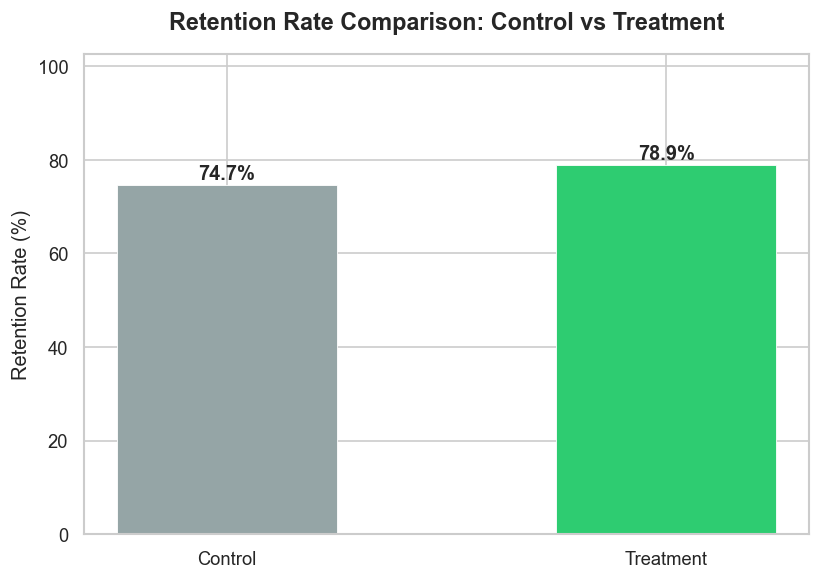

In [8]:
# Retention rate comparison between groups
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Control', 'Treatment'],
              [control_rate * 100, treatment_rate * 100],
              color=['#95a5a6', '#2ecc71'], edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, [control_rate * 100, treatment_rate * 100]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Retention Rate Comparison: Control vs Treatment',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Retention Rate (%)')
ax.set_ylim(0, max(control_rate, treatment_rate) * 130)
plt.tight_layout()
plt.show()


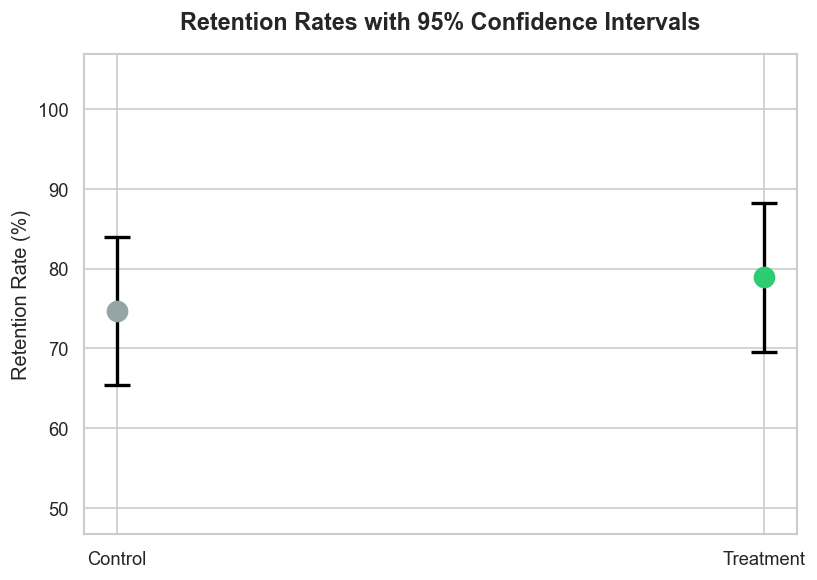

In [9]:
# Confidence interval visualization
rates = [control_rate * 100, treatment_rate * 100]
errors = [1.96 * se_diff * 100, 1.96 * se_diff * 100]
groups = ['Control', 'Treatment']
colors = ['#95a5a6', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (g, r, e, c) in enumerate(zip(groups, rates, errors, colors)):
    ax.errorbar(g, r, yerr=e, fmt='none', ecolor='black', elinewidth=2, capsize=8, capthick=2)
    ax.plot(g, r, 'o', markersize=12, color=c, zorder=5)
ax.set_title('Retention Rates with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Retention Rate (%)')
ax.set_ylim(min(rates) - max(errors) * 3, max(rates) + max(errors) * 3)
plt.tight_layout()
plt.show()


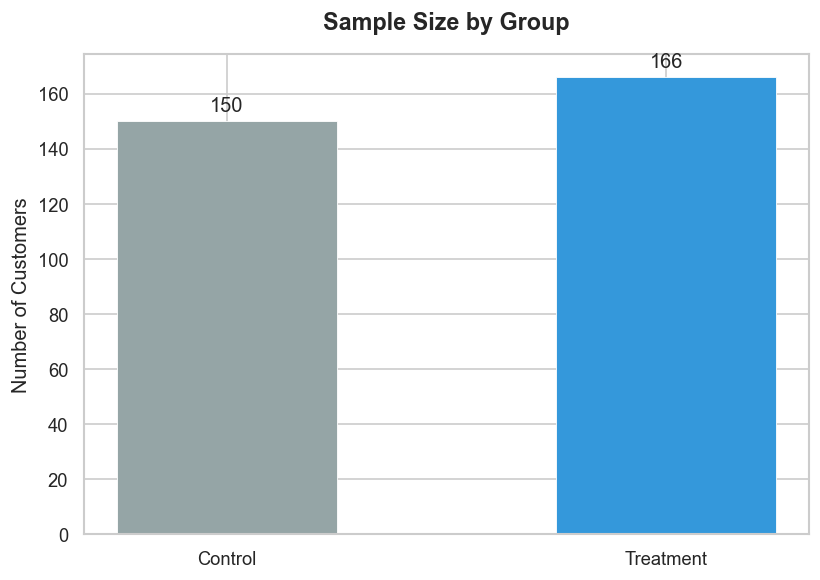

In [10]:
# Sample size by group
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Control', 'Treatment'], [control_total, treatment_total],
              color=['#95a5a6', '#3498db'], edgecolor='white', linewidth=0.5, width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=12)
ax.set_title('Sample Size by Group', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


## Step 8: Business Impact Estimation

I'm translating statistical results into business metrics.

In [11]:
# Business impact assumptions
avg_customer_lifetime_value = 1000  # dollars
campaign_cost_per_customer = 0.50   # SMS cost
total_at_risk_customers = at_risk_count

print("BUSINESS IMPACT ANALYSIS:")
print("=" * 60)
print(f"\nAssumptions:")
print(f"  Average Customer LTV: \${avg_customer_lifetime_value:.2f}")
print(f"  Campaign cost per customer: \${campaign_cost_per_customer:.2f}")
print(f"  Total at-risk customers: {total_at_risk_customers}")

# Full population impact
customers_retained_control = int(total_at_risk_customers * 0.5 * control_rate)
customers_retained_treatment = int(total_at_risk_customers * 0.5 * treatment_rate)
customers_retained_incremental = customers_retained_treatment - customers_retained_control

revenue_from_retained = customers_retained_incremental * avg_customer_lifetime_value
campaign_cost = total_at_risk_customers * campaign_cost_per_customer
net_revenue = revenue_from_retained - campaign_cost
roi = (net_revenue / campaign_cost) * 100

print(f"\nCampaign Results (Full At-Risk Segment):")
print(f"  Incremental customers retained: {customers_retained_incremental}")
print(f"  Revenue from retention: \${revenue_from_retained:,.0f}")
print(f"  Campaign cost: \${campaign_cost:,.0f}")
print(f"  Net revenue: \${net_revenue:,.0f}")
print(f"  ROI: {roi:.0f}%")

# Cost per retained customer
cost_per_retained = campaign_cost / customers_retained_incremental if customers_retained_incremental > 0 else float('inf')
print(f"\nCost per retained customer: \${cost_per_retained:.2f}")

print("=" * 60)

BUSINESS IMPACT ANALYSIS:

Assumptions:
  Average Customer LTV: \$1000.00
  Campaign cost per customer: \$0.50
  Total at-risk customers: 316

Campaign Results (Full At-Risk Segment):
  Incremental customers retained: 7
  Revenue from retention: \$7,000
  Campaign cost: \$158
  Net revenue: \$6,842
  ROI: 4330%

Cost per retained customer: \$22.57


## Step 9: Recommendations

Based on the test results, here are my recommendations for the business.

In [12]:
print("RECOMMENDATIONS:")
print("=" * 60)

if p_value < 0.05:
    print(f"✓ POSITIVE RESULT: The SMS campaign shows statistically significant")
    print(f"  improvement in retention (p={p_value:.4f})")
    print(f"")
    print(f"NEXT STEPS:")
    print(f"  1. Scale campaign to full at-risk segment")
    print(f"  2. Expected incremental retention: {customers_retained_incremental} customers")
    print(f"  3. Projected revenue impact: \${net_revenue:,.0f}")
    print(f"  4. Monitor actual results vs. simulation")
else:
    print(f"✗ INCONCLUSIVE RESULT: The SMS campaign did not show")
    print(f"  statistically significant improvement (p={p_value:.4f})")
    print(f"")
    print(f"NEXT STEPS:")
    print(f"  1. Increase sample size for more power")
    print(f"  2. Test alternative messaging or timing")
    print(f"  3. Segment by customer characteristics")
    print(f"  4. Combine with other retention tactics")

print(f"\nAbsolute improvement: {absolute_lift:.2f} percentage points")
print("=" * 60)

RECOMMENDATIONS:
✗ INCONCLUSIVE RESULT: The SMS campaign did not show
  statistically significant improvement (p=0.4465)

NEXT STEPS:
  1. Increase sample size for more power
  2. Test alternative messaging or timing
  3. Segment by customer characteristics
  4. Combine with other retention tactics

Absolute improvement: 4.25 percentage points


### What I Took Away from the A/B Test

The treatment group retained 78.9% of at-risk customers versus 74.7% in the control, a 4.25 percentage point lift. Directionally, that's exactly what we'd want to see from an SMS re-engagement campaign. But neither the chi-squared test (p=0.45) nor the z-test (p=0.19) reached significance, and the 95% confidence interval crosses zero (-5.08% to +13.57%). The study was underpowered from the start: the power analysis called for 1,505 customers and we had 316. Cohen's h of 0.10 barely registers as a small effect.

The business math looks attractive on the surface. At \$0.50 per SMS with 7 incremental retentions, the cost per save comes out to \$22.57 against a \$1,000 LTV assumption, which would be a 4,330% ROI. But those numbers sit on top of simulated outcomes, a placeholder LTV, and a test that couldn't confirm the effect is real. The honest read is that this is a promising pilot with encouraging direction, not a proven result.

If I were presenting this to a retention team, the recommendation would be straightforward: don't roll out yet, but don't kill it either. The campaign economics are cheap enough that even a modest lift pays for itself. What's needed is a properly powered follow-up with 750+ customers per group, run over 60-90 days with actual churn outcomes tracked rather than simulated. If the 4.25pp lift holds at that scale, the case becomes easy. If it shrinks below 2pp, the operational overhead probably isn't worth it. Either way, this analysis built the testing framework and established the statistical benchmarks for that next step.